# 04. Prior 설계 분석 — Black-Litterman 입력 검증 EDA

> **이 노트북의 위치**
> - **목적**: BL 입력 설계의 *분석적 근거*를 제공하는 보조 EDA
> - **범위**: ① 공분산 추정 안정성(p/T) + ② Prior 선택(시총 vs 1/N) 영향
> - **최종 portfolio 백테스트는 [`final/99_run.ipynb`](../../final/99_run.ipynb)** 에서 수행 (19개 실험, baseline Sharpe 1.106 1위 입증)
>
> **04의 진짜 가치**
> - p/T 진단: 일별 Σ로 N=500까지 안정 (final에 없는 분석)
> - π 상관 0.9865 발견: "Prior 영향 제한적" 사전 예측 → final 결과(baseline 1.106 vs prior_eq 1.105)와 일치
> - **이 두 발견이 발표/리포트의 핵심 논거**

## 분석 항목

1. **Part 1 — p/T 비율 진단**: BL 공분산 추정의 통계적 안정성
2. **Part 2 — Prior 비교**: 시가총액 vs 1/N의 π 분포·집중도·방향성 일치도

## 분석 기간

- 패널 기간: 2004-01 ~ 2025-12 (264개월, 620 티커)
- 평가 기간: 2010-01 ~ 2024-12 (180개월, OOS)

## 설계 기준

| 파라미터 | 값 |
|---------|----|
| `TRAIN_WINDOW` | 60 (월) |
| `TAU` | 0.1 |
| 비교 대상 Prior | `mcap` / `equal(1/N)` |
| 유니버스 | 패널 그대로 (raw, point-in-time) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.set_loglevel('error')   # cairo 백엔드 폰트 경고 차단
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import logging
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from scipy import stats
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
for _name in ('matplotlib', 'matplotlib.font_manager', 'matplotlib.backends.backend_cairo', 'matplotlib._text_helpers'):
    logging.getLogger(_name).setLevel(logging.ERROR)

# 한글 폰트 + Unicode minus(U+2212) 폰트 fallback 체인
if platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path('김윤서/low_risk') if not Path('data').exists() else Path('.')
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs'

TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2010-01-01'
END_PRED     = '2024-12-31'  # 15년 OOS 종료

# 데이터 로드
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[(all_dates >= START_PRED) & (all_dates <= END_PRED)]

ret_pivot = panel['ret_1m'].unstack('ticker')

# spy_ret / rf_1m 은 패널의 컬럼으로 저장됨 (ticker 인덱스 없음)
# ret_pivot['SPY'] 로 접근하면 NoneType → .get() 호출 시 AttributeError 발생
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

print(f'패널 로드: {panel.shape}, 예측기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'전체 유니버스 종목: {panel.index.get_level_values("ticker").nunique()}개')
print(f'spy_series: {spy_series.shape[0]}개월, NaN={spy_series.isna().sum()}개')
print(f'rf_series:  {rf_series.shape[0]}개월,  NaN={rf_series.isna().sum()}개')

패널 로드: (108135, 11), 예측기간: 2010-01-31 ~ 2024-12-31 (180개월)
전체 유니버스 종목: 620개
spy_series: 264개월, NaN=1개
rf_series:  264개월,  NaN=0개


## Part 1. p/T 비율 진단 — 유니버스 크기와 공분산 추정 품질

BL 포트폴리오에서 공분산 행렬 Σ(p×p)를 추정할 때, **p/T 비율**이 추정 품질을 결정한다.

| p/T 범위 | 상태 |
|---------|------|
| < 0.5 | 양호 — Ledoit-Wolf 안정 수렴 |
| 0.5 ~ 1.0 | 주의 — 추정 분산 증가 |
| > 1.0 | 불안정 — singular 위험, shrinkage 수렴 보장 불가 |

**T 기준: 일별 수익률 사용** (T = TRAIN_WINDOW × 21 = 60 × 21 = **1260일**)

월별 데이터(T=60)로는 N=300만 되어도 p/T=5로 불안정하다. 본 프로젝트는 일별 수익률로 Σ를 추정하고
스케일링(Σ_monthly ≈ Σ_daily × 21)으로 월별 단위에 맞추므로 T 기준이 1260이 된다.
일별 데이터 사용으로 N=500 수준까지 양호 범위에 들어간다.

In [2]:
# ── p/T 비율 진단 ────────────────────────────────────────────
# 공분산 행렬 Σ(p×p) 추정 품질은 p/T 비율에 직접 의존
# 본 프로젝트는 일별 수익률로 Σ 추정 → T = TRAIN_WINDOW × 21 (일별 기준)

T_DAILY = TRAIN_WINDOW * 21   # 60개월 × 21영업일 = 1260일

cov_qual = []
print(f'=== p/T 비율 진단 (T = TRAIN_WINDOW × 21 = {T_DAILY}일, 일별 수익률 기준) ===')
print('p/T < 0.5: 양호  |  0.5~1.0: 주의  |  > 1.0: 불안정')
print()
print(f'{"N":>8}  {"p/T":>6}  {"등급":>8}')
print('-' * 30)
for n in [50, 100, 200, 300, 400, 500]:
    pt    = n / T_DAILY
    grade = '양호' if pt < 0.5 else ('주의' if pt < 1.0 else '불안정')
    print(f'{n:>8}  {pt:>6.2f}  {grade:>8}')
    cov_qual.append({'N': n, 'p/T': pt, '등급': grade})

# 현재 유니버스 평균 종목수
avg_full = panel.groupby(level='date')['vol_21d'].count().mean()
pt_full  = avg_full / T_DAILY
print()
print(f'현재 전체 유니버스 평균 종목수 ≈ {avg_full:.0f}개  →  p/T = {pt_full:.2f}  (일별 T=1260 기준)')

# 참고: 월별 T=60 기준이었다면 어떻게 됐을지
print()
print(f'[참고] 월별 T={TRAIN_WINDOW} 기준이라면:')
for n in [50, 100, 200, 300, 500]:
    pt_m = n / TRAIN_WINDOW
    flag = '  ← 매우 불안정' if pt_m > 1.0 else ''
    print(f'  N={n:>4}: p/T = {pt_m:.2f}{flag}')
print('→ 일별 데이터 사용으로 N=500 수준까지도 양호 범위로 진입.')

=== p/T 비율 진단 (T = TRAIN_WINDOW × 21 = 1260일, 일별 수익률 기준) ===
p/T < 0.5: 양호  |  0.5~1.0: 주의  |  > 1.0: 불안정

       N     p/T        등급
------------------------------
      50    0.04        양호
     100    0.08        양호
     200    0.16        양호
     300    0.24        양호
     400    0.32        양호
     500    0.40        양호

현재 전체 유니버스 평균 종목수 ≈ 408개  →  p/T = 0.32  (일별 T=1260 기준)

[참고] 월별 T=60 기준이라면:
  N=  50: p/T = 0.83
  N= 100: p/T = 1.67  ← 매우 불안정
  N= 200: p/T = 3.33  ← 매우 불안정
  N= 300: p/T = 5.00  ← 매우 불안정
  N= 500: p/T = 8.33  ← 매우 불안정
→ 일별 데이터 사용으로 N=500 수준까지도 양호 범위로 진입.


## Part 2. Prior 3-way 비교 — 시가총액 vs 1/N vs Risk Parity

BL 모형에서 π = λΣw_mkt는 뷰(Q)를 반영하기 전의 기본 기대수익률. **세 가지 prior 후보**를 비교한다.

### 비교 대상

| Prior | 가중 방식 | 출발 가정 | 본 프로젝트 적합성 |
|---|---|---|---|
| `capm_mcap` | 시가총액 비례 | "시장이 정한 비중이 답" | 평시 baseline (BL 정통) |
| `capm_eq` | 1/N 균등 | "정보 무시, 모든 종목 동등" | selection bias 중립 |
| **`capm_rp`** | **1/σ 정규화** (Risk Parity) | **"위험 분산이 최우선"** | **저위험 anomaly 가설과 일관** ✓ |

### Risk Parity 정의

$$w_i^{RP} = \frac{1/\sigma_i}{\sum_j 1/\sigma_j}$$

→ 저변동 종목에 큰 비중, 고변동 종목에 작은 비중.
→ 위험 기여도 $w_i \times \sigma_i$가 모든 자산에서 동일 (자산 독립 가정).

### 평가 지표
- **HHI(w)**: prior의 집중도 (낮을수록 분산)
- **유효 종목 수** (1/HHI): 실질적으로 비중을 받는 종목 수
- **π 표준편차**: 균형수익률의 분산도 (Σ에 의존)
- **π 상관계수** (3 pair): 두 prior가 만든 신호의 방향성 일치도

### 핵심 질문
- prior 선택이 π에 의미 있는 차이를 만드는가?
- RP는 1/N과 차별화되는가, 비슷한가?
- 본 프로젝트가 어느 prior와 가장 일관되는가?

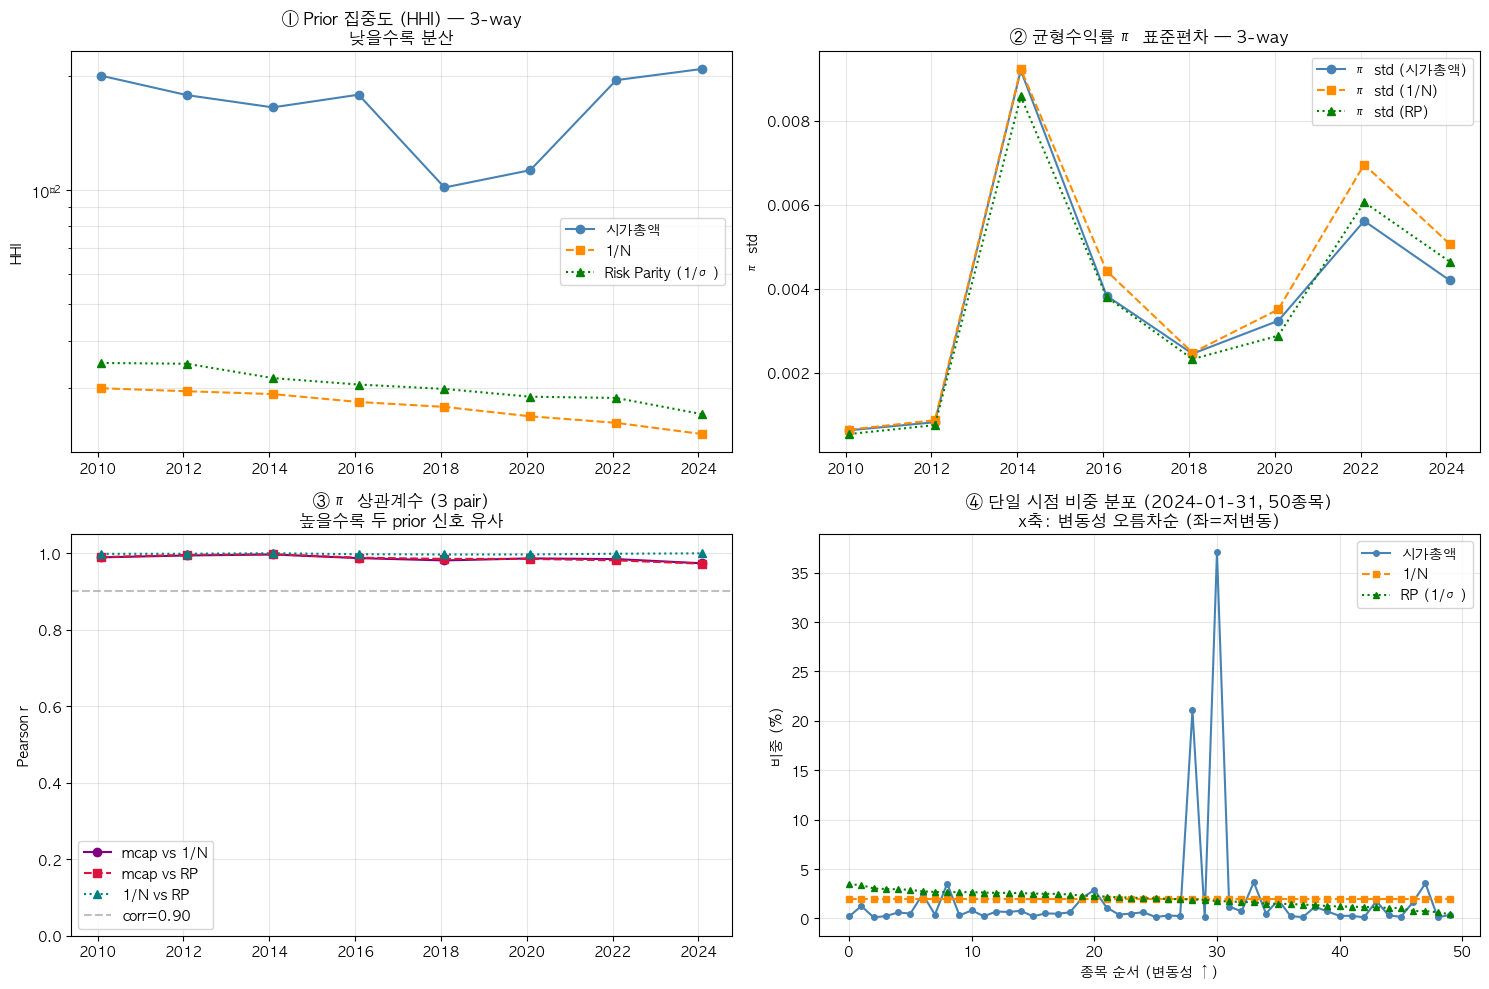

Risk Parity Prior 추가 — 3-way 비교 수치 요약

지표                                   mcap        1/N   RP (1/σ)
------------------------------------------------------------
HHI 평균                            0.01672    0.00268    0.00305
유효 종목 수 (1/HHI)                        60        373        328
π 표준편차 평균                         0.00375    0.00415    0.00370

=== π 상관계수 (3 pair) ===
mcap vs 1/N (기존 발견)                0.9865
mcap vs RP                         0.9867
1/N vs RP                          0.9981

=== 핵심 해석 ===
• mcap-1/N 상관 0.9865: 기존 발견 (Part 2)
• mcap-RP 상관 0.9867: RP가 mcap과 동등
• 1/N-RP 상관 0.9981: RP가 1/N과 동등

• HHI 위치: 1/N(0.00268) < RP(0.00305) < mcap(0.01672)
  → RP는 1/N과 mcap 사이의 중간 분산도


In [3]:
# ── Part 2. Prior 3-way 비교 (mcap, 1/N, Risk Parity) ──────
# 2년마다 샘플링한 시점들에서 3가지 prior의 π 분포·집중도·상관계수 비교
sample_pred_dates = pred_dates[::24]  # 2년마다 1개 시점


# RP 가중치: 단순 1/σ 정규화 (자산 독립 가정)
# 매 시점 mcap, 1/N, RP 세 가지 prior로 π를 계산하고 비교

pi_3way = []

for pred_date in sample_pred_dates:
    idx         = all_dates.get_loc(pred_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

    month_df = panel.xs(pred_date, level='date').dropna(subset=['vol_21d', 'log_mcap', 'ret_1m'])
    if len(month_df) < 30:
        continue

    universe  = month_df.index.tolist()
    thresh    = int(len(train_dates) * 0.7)
    mask      = (panel.index.get_level_values('date').isin(train_dates) &
                 panel.index.get_level_values('ticker').isin(universe))
    ret_counts = panel.loc[mask, 'ret_1m'].dropna().groupby(level='ticker').count()
    valid_tix  = ret_counts[ret_counts >= thresh].index.tolist()
    if len(valid_tix) < 20:
        continue

    ret_slice  = ret_pivot.reindex(index=train_dates, columns=valid_tix).fillna(0)
    Sigma      = compute_sigma(ret_slice)
    month_sub  = month_df.reindex(valid_tix)
    mcap       = np.exp(month_sub['log_mcap'])
    vol        = month_sub['vol_21d']

    # 3가지 Prior 정의
    w_mcap  = mcap / mcap.sum()
    w_equal = pd.Series(1 / len(valid_tix), index=valid_tix)
    inv_vol = 1.0 / vol.replace(0, np.nan).dropna()
    w_rp    = inv_vol / inv_vol.sum()
    w_rp    = w_rp.reindex(valid_tix).fillna(0)
    if w_rp.sum() > 0:
        w_rp = w_rp / w_rp.sum()

    rf_s       = rf_series.reindex(train_dates)
    spy_s      = spy_series.reindex(train_dates) if spy_series is not None else pd.Series(0.0, index=train_dates)
    spy_excess = (spy_s - rf_s).mean()
    sigma2_mkt = spy_s.var()

    pi_mcap,  _ = compute_pi(Sigma, w_mcap,  spy_excess, sigma2_mkt)
    pi_equal, _ = compute_pi(Sigma, w_equal, spy_excess, sigma2_mkt)
    pi_rp,    _ = compute_pi(Sigma, w_rp,    spy_excess, sigma2_mkt)

    pi_3way.append({
        'date'         : pred_date,
        'n_valid'      : len(valid_tix),
        'hhi_mcap'     : float((w_mcap  ** 2).sum()),
        'hhi_equal'    : float((w_equal ** 2).sum()),
        'hhi_rp'       : float((w_rp    ** 2).sum()),
        'pi_std_mcap'  : pi_mcap.std(),
        'pi_std_equal' : pi_equal.std(),
        'pi_std_rp'    : pi_rp.std(),
        'corr_mcap_eq' : float(np.corrcoef(pi_mcap,  pi_equal)[0, 1]),
        'corr_mcap_rp' : float(np.corrcoef(pi_mcap,  pi_rp   )[0, 1]),
        'corr_eq_rp'   : float(np.corrcoef(pi_equal, pi_rp   )[0, 1]),
    })

df_3 = pd.DataFrame(pi_3way).set_index('date')

# ── 시각화 (2×2 패널) ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ① Prior HHI 3-way
ax = axes[0, 0]
ax.plot(df_3.index, df_3['hhi_mcap'],  'o-',  label='시가총액', color='steelblue')
ax.plot(df_3.index, df_3['hhi_equal'], 's--', label='1/N',     color='darkorange')
ax.plot(df_3.index, df_3['hhi_rp'],    '^:',  label='Risk Parity (1/σ)', color='green')
ax.set_title('① Prior 집중도 (HHI) — 3-way\n낮을수록 분산')
ax.set_ylabel('HHI')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')

# ② π 표준편차 3-way
ax = axes[0, 1]
ax.plot(df_3.index, df_3['pi_std_mcap'],  'o-',  label='π std (시가총액)', color='steelblue')
ax.plot(df_3.index, df_3['pi_std_equal'], 's--', label='π std (1/N)',     color='darkorange')
ax.plot(df_3.index, df_3['pi_std_rp'],    '^:',  label='π std (RP)',      color='green')
ax.set_title('② 균형수익률 π 표준편차 — 3-way')
ax.set_ylabel('π std')
ax.legend()
ax.grid(alpha=0.3)

# ③ π 상관계수 (3 pair)
ax = axes[1, 0]
ax.plot(df_3.index, df_3['corr_mcap_eq'], 'o-',  label='mcap vs 1/N',       color='purple')
ax.plot(df_3.index, df_3['corr_mcap_rp'], 's--', label='mcap vs RP',        color='crimson')
ax.plot(df_3.index, df_3['corr_eq_rp'],   '^:',  label='1/N vs RP',         color='teal')
ax.axhline(0.9, ls='--', color='gray', alpha=0.5, label='corr=0.90')
ax.set_title('③ π 상관계수 (3 pair)\n높을수록 두 prior 신호 유사')
ax.set_ylabel('Pearson r')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3)

# ④ 단일 시점 비중 분포 (가장 최근)
ax = axes[1, 1]
last_date = sample_pred_dates[-1]
month_last = panel.xs(last_date, level='date').dropna(subset=['vol_21d', 'log_mcap']).head(50)
mcap_l = np.exp(month_last['log_mcap']); mcap_l = mcap_l / mcap_l.sum()
vol_l  = month_last['vol_21d']
inv_l  = 1/vol_l;     w_rp_l = inv_l / inv_l.sum()
w_eq_l = pd.Series(1/len(month_last), index=month_last.index)

# 변동성 정렬 후 plot
order = vol_l.sort_values().index
ax.plot(range(len(order)), mcap_l.loc[order].values * 100, 'o-',  label='시가총액', color='steelblue', markersize=4)
ax.plot(range(len(order)), w_eq_l.loc[order].values * 100, 's--', label='1/N',     color='darkorange', markersize=4)
ax.plot(range(len(order)), w_rp_l.loc[order].values * 100, '^:',  label='RP (1/σ)', color='green', markersize=4)
ax.set_title(f'④ 단일 시점 비중 분포 ({last_date.date()}, 50종목)\nx축: 변동성 오름차순 (좌=저변동)')
ax.set_xlabel('종목 순서 (변동성 ↑)')
ax.set_ylabel('비중 (%)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_prior_3way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 수치 요약 ─────────────────────────────────────────────────
print('=' * 70)
print('Risk Parity Prior 추가 — 3-way 비교 수치 요약')
print('=' * 70)
print()
print(f'{"지표":<30} {"mcap":>10} {"1/N":>10} {"RP (1/σ)":>10}')
print('-' * 60)
print(f'{"HHI 평균":<30} {df_3["hhi_mcap"].mean():>10.5f} {df_3["hhi_equal"].mean():>10.5f} {df_3["hhi_rp"].mean():>10.5f}')
print(f'{"유효 종목 수 (1/HHI)":<30} {1/df_3["hhi_mcap"].mean():>10.0f} {1/df_3["hhi_equal"].mean():>10.0f} {1/df_3["hhi_rp"].mean():>10.0f}')
print(f'{"π 표준편차 평균":<30} {df_3["pi_std_mcap"].mean():>10.5f} {df_3["pi_std_equal"].mean():>10.5f} {df_3["pi_std_rp"].mean():>10.5f}')
print()
print('=== π 상관계수 (3 pair) ===')
print(f'{"mcap vs 1/N (기존 발견)":<30} {df_3["corr_mcap_eq"].mean():>10.4f}')
print(f'{"mcap vs RP":<30} {df_3["corr_mcap_rp"].mean():>10.4f}')
print(f'{"1/N vs RP":<30} {df_3["corr_eq_rp"].mean():>10.4f}')
print()
print('=== 핵심 해석 ===')
mcap_eq = df_3['corr_mcap_eq'].mean()
mcap_rp = df_3['corr_mcap_rp'].mean()
eq_rp   = df_3['corr_eq_rp'].mean()
print(f'• mcap-1/N 상관 {mcap_eq:.4f}: 기존 발견 (Part 2)')
print(f'• mcap-RP 상관 {mcap_rp:.4f}: RP가 mcap과 {("동등" if mcap_rp > 0.9 else "차별화")}')
print(f'• 1/N-RP 상관 {eq_rp:.4f}: RP가 1/N과 {("동등" if eq_rp > 0.9 else "차별화")}')
print()
hhi_rp = df_3['hhi_rp'].mean()
hhi_mcap = df_3['hhi_mcap'].mean()
hhi_eq = df_3['hhi_equal'].mean()
print(f'• HHI 위치: 1/N({hhi_eq:.5f}) < RP({hhi_rp:.5f}) < mcap({hhi_mcap:.5f})')
print(f'  → RP는 1/N과 mcap 사이의 중간 분산도')

## Part 3. 미니 BL 시뮬레이션 — 사후 비중 단계에서 prior 차이 검증

Part 2는 *신호 단계*(π) 비교. 본 절은 BL 전체 파이프라인을 직접 돌려 **사후 비중 w\*** 단계에서 prior 차이가 어떻게 나타나는지 확인한다.

### 시뮬레이션 절차

각 prior(mcap, 1/N, RP)에 대해:

```
prior w  →  π = λΣw  →  μ_BL = π + τΣP^T(τPΣP^T+Ω)^-1(Q-Pπ)
                    →  optimize_portfolio (long-only)  →  w*
```

### 시점 선택

3개 대표 시점 (분석 기간 균등 분포):
- **2013-10**: 정상기 (회복 후)
- **2017-07**: 정상기 (저변동 시기)
- **2024-01**: 최근 (인플레+AI 붐 환경)

### 검증 지표

| 지표 | 의미 |
|---|---|
| **max\|w\*\|** | 사후 비중의 단일 종목 최대치 — 위험 집중도 |
| **HHI(w\*)** | 사후 비중의 분산도 (낮을수록 분산) |
| **유효 종목 수** | 1/HHI — 실질 비중을 받는 종목 수 |
| **top10 비중 합** | 상위 10종목의 합 — 메가캡 의존도 |
| **w\* 상관계수** | 두 prior 사후 비중의 일치도 |

### 핵심 질문
- 신호 단계(π)에서 99%+ 일치하던 prior들이 portfolio 단계에서도 여전히 같은 결과를 만드나?
- MVO 최적화 + 제약식이 prior 차이를 *감쇠*시키나, *증폭*시키나?

### 의의
04 Part 2의 신호 단계 발견과 portfolio 단계의 차이를 *직접 측정*. final/99_run의 19개 실험에 의존하지 않고 EDA 안에서 즉시 검증.


시점: 2013-10-31



방식          max|w*|    HHI(w*)      유효 종목    top10 합
------------------------------------------------------------
mcap          8.08%    0.03561         28     49.63%
1/N           4.77%    0.01969         51     32.76%
RP            4.27%    0.01935         52     31.70%

사후 비중 w* 상관계수:
  mcap vs 1/N: 0.8348
  mcap vs RP: 0.8280
  1/N vs RP: 0.9920

시점: 2017-07-31



방식          max|w*|    HHI(w*)      유효 종목    top10 합
------------------------------------------------------------
mcap          6.09%    0.01930         52     34.81%
1/N           3.13%    0.00946        106     19.51%
RP            2.80%    0.00961        104     18.62%

사후 비중 w* 상관계수:
  mcap vs 1/N: 0.8072
  mcap vs RP: 0.7890
  1/N vs RP: 0.9704

시점: 2024-01-31



방식          max|w*|    HHI(w*)      유효 종목    top10 합
------------------------------------------------------------
mcap          6.39%    0.02406         42     39.33%
1/N           3.57%    0.01348         74     24.57%
RP            3.96%    0.01468         68     26.43%

사후 비중 w* 상관계수:
  mcap vs 1/N: 0.6032
  mcap vs RP: 0.6322
  1/N vs RP: 0.9879


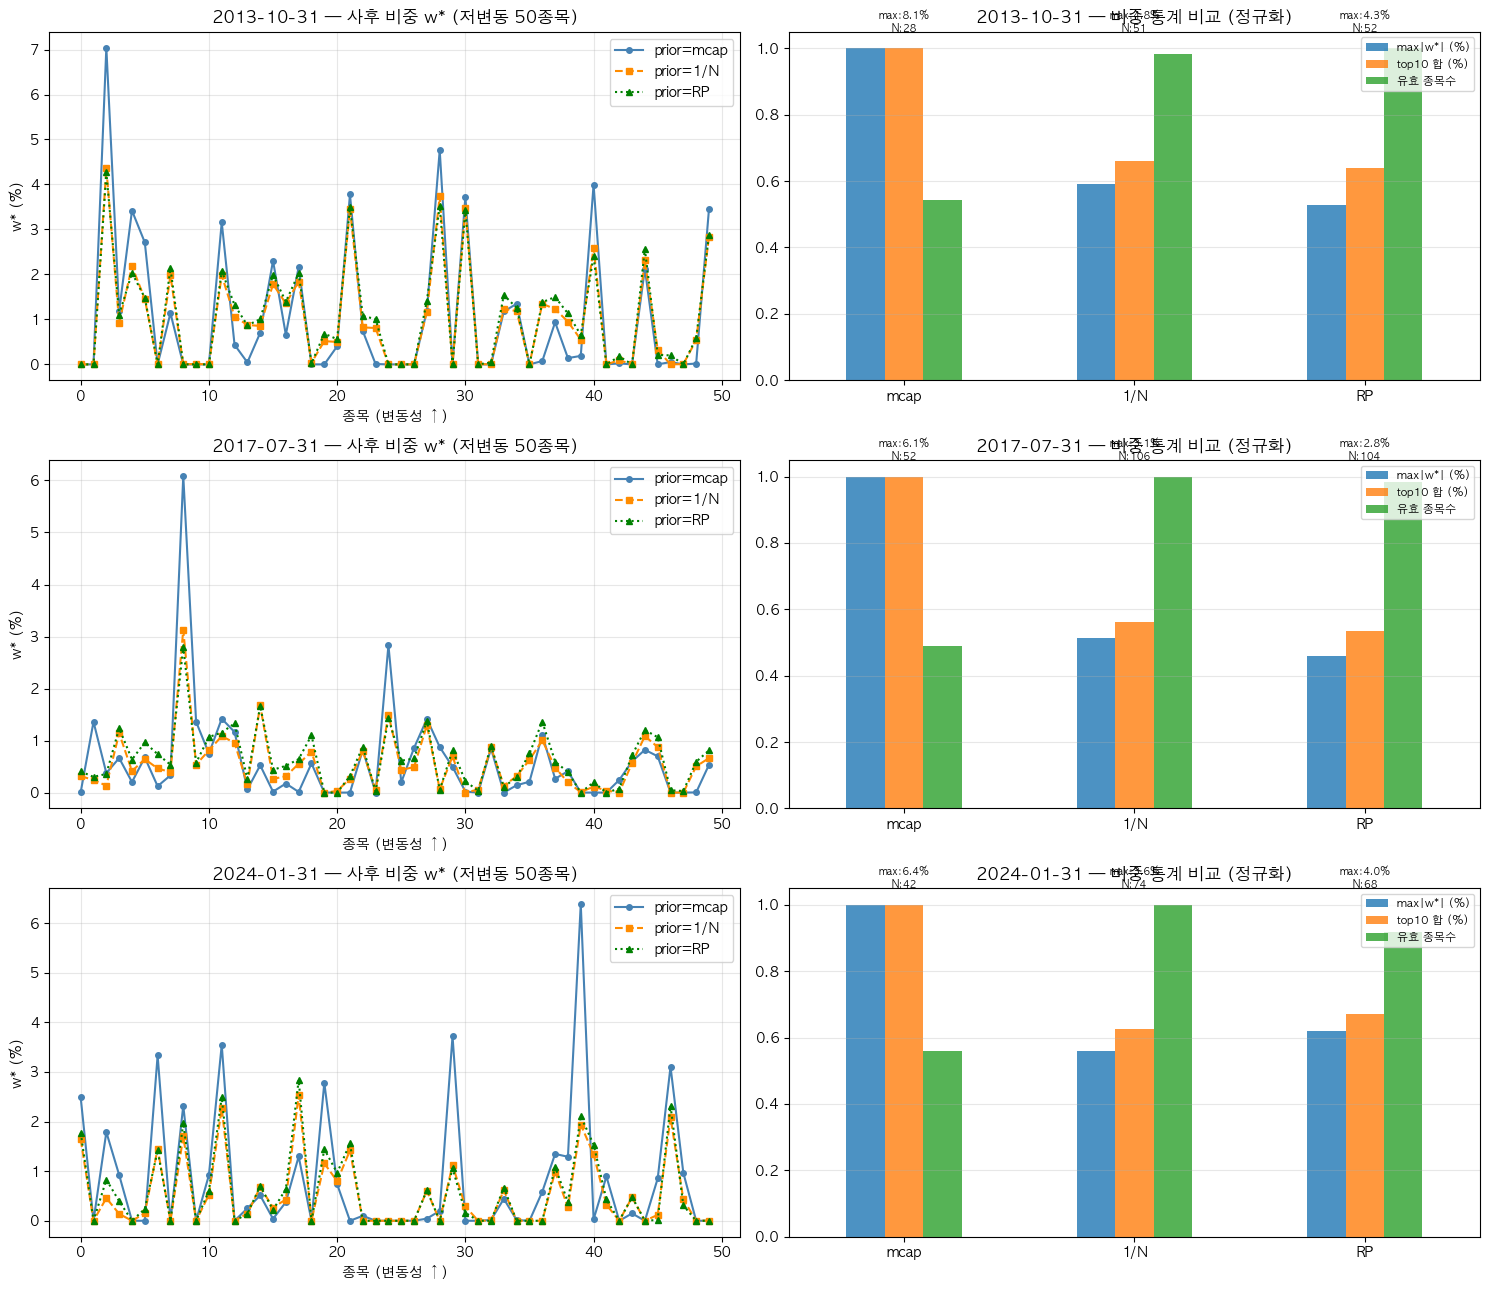


Part 4 종합 — 사후 비중 w* 단계의 prior 효과

사후 비중 w* 상관계수 (3시점 평균):
   mcap vs 1/N  : 0.7484  (시점별: ['0.835', '0.807', '0.603'])
   mcap vs RP   : 0.7497  (시점별: ['0.828', '0.789', '0.632'])
    1/N vs RP   : 0.9834  (시점별: ['0.992', '0.970', '0.988'])

→ Part 2·3 신호단계 발견 (π 상관)과 비교:
  π 상관:  mcap-1/N 0.9865 / mcap-RP 0.9867 / 1/N-RP 0.9981
  w* 상관: mcap-1/N 0.7484 / mcap-RP 0.7497 / 1/N-RP 0.9834


In [4]:
# ── Part 3. 미니 BL 시뮬레이션 (3 prior × 3 시점) ────────────
# 3개 시점 샘플 × 3개 prior로 BL 전체 파이프라인 비교

# 대표 시점 3개 (분석 기간 균등 분포)
sim_dates = [pred_dates[len(pred_dates)//4],     # ~2013-12 (정상기)
             pred_dates[len(pred_dates)//2],     # ~2017-12 (정상기)
             pred_dates[-12]]                     # 2024-01 (최근, AI 붐)

# BL 파라미터
TAU_BL    = 0.1
Q_VIEW    = 0.003   # 월 0.3% (저위험 우위 뷰)
MAX_W     = 0.10    # (참고용, bl_utils.optimize_portfolio는 max_weight 미지원 → 자동 0~1)
PCT       = PCT_GROUP  # 0.30

results_4 = []

for sim_date in sim_dates:
    print(f'\n{"="*70}')
    print(f'시점: {sim_date.date()}')
    print('=' * 70)

    idx         = all_dates.get_loc(sim_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

    month_df = panel.xs(sim_date, level='date').dropna(subset=['vol_21d', 'log_mcap', 'ret_1m'])
    universe = month_df.index.tolist()
    thresh   = int(len(train_dates) * 0.7)
    mask     = (panel.index.get_level_values('date').isin(train_dates) &
                panel.index.get_level_values('ticker').isin(universe))
    ret_counts = panel.loc[mask, 'ret_1m'].dropna().groupby(level='ticker').count()
    valid_tix  = ret_counts[ret_counts >= thresh].index.tolist()

    ret_slice  = ret_pivot.reindex(index=train_dates, columns=valid_tix).fillna(0)
    Sigma      = compute_sigma(ret_slice)
    month_sub  = month_df.reindex(valid_tix)
    mcap       = np.exp(month_sub['log_mcap'])
    vol        = month_sub['vol_21d']

    # 3가지 prior weights
    w_mcap_p  = mcap / mcap.sum()
    w_equal_p = pd.Series(1 / len(valid_tix), index=valid_tix)
    inv_vol   = 1.0 / vol.replace(0, np.nan).dropna()
    w_rp_p    = (inv_vol / inv_vol.sum()).reindex(valid_tix).fillna(0)
    if w_rp_p.sum() > 0:
        w_rp_p = w_rp_p / w_rp_p.sum()

    # SPY 통계
    rf_s       = rf_series.reindex(train_dates)
    spy_s      = spy_series.reindex(train_dates) if spy_series is not None else pd.Series(0.0, index=train_dates)
    spy_excess = (spy_s - rf_s).mean()
    sigma2_mkt = spy_s.var()

    # P 행렬 (mcap 가중, 상하위 30%)
    P = build_P(vol, mcap, pct=PCT)

    # 각 prior로 BL → MVO
    star_dict = {}
    for name, w_prior in [('mcap', w_mcap_p), ('1/N', w_equal_p), ('RP', w_rp_p)]:
        pi, lam = compute_pi(Sigma, w_prior, spy_excess, sigma2_mkt)
        omega   = compute_omega(P, Sigma, TAU_BL)
        mu_BL = black_litterman(pi, Sigma, P, Q_VIEW, omega, TAU_BL)
        w_star = optimize_portfolio(mu_BL, Sigma, lam)
        star_dict[name] = w_star

    # 비중 비교 통계
    print(f'\n{"방식":<8} {"max|w*|":>10} {"HHI(w*)":>10} {"유효 종목":>10} {"top10 합":>10}')
    print('-' * 60)
    for name, w_star in star_dict.items():
        max_w  = w_star.abs().max()
        hhi    = (w_star ** 2).sum()
        eff_n  = 1 / hhi if hhi > 0 else np.nan
        top10  = w_star.nlargest(10).sum()
        print(f'{name:<8} {max_w*100:>9.2f}% {hhi:>10.5f} {eff_n:>10.0f} {top10*100:>9.2f}%')

    # 사후 비중 상관계수 (두 prior 간)
    print(f'\n사후 비중 w* 상관계수:')
    for n1, n2 in [('mcap', '1/N'), ('mcap', 'RP'), ('1/N', 'RP')]:
        c = float(np.corrcoef(star_dict[n1].values, star_dict[n2].values)[0, 1])
        print(f'  {n1} vs {n2}: {c:.4f}')

    results_4.append({
        'date': sim_date,
        'star_dict': star_dict,
        'mcap': mcap,
        'vol': vol,
    })

# ── 시각화: 사후 비중 분포 비교 (3시점 × 3 prior) ───────────────
fig, axes = plt.subplots(3, 2, figsize=(15, 13))

for row, r in enumerate(results_4):
    sd = r['star_dict']
    vol_r = r['vol']

    # 좌: 비중 정렬 (변동성 오름차순)
    ax = axes[row, 0]
    vol_sorted = vol_r.sort_values()
    common = vol_sorted.index.intersection(sd['mcap'].index)
    vol_sorted = vol_sorted.loc[common]
    n_show = min(50, len(common))
    show_idx = vol_sorted.index[:n_show]

    x = range(n_show)
    ax.plot(x, sd['mcap'].loc[show_idx].values * 100,  'o-', label='prior=mcap', color='steelblue', markersize=4)
    ax.plot(x, sd['1/N'].loc[show_idx].values * 100,   's--', label='prior=1/N',   color='darkorange', markersize=4)
    ax.plot(x, sd['RP'].loc[show_idx].values * 100,    '^:', label='prior=RP',     color='green', markersize=4)
    ax.set_title(f'{r["date"].date()} — 사후 비중 w* (저변동 50종목)')
    ax.set_xlabel('종목 (변동성 ↑)')
    ax.set_ylabel('w* (%)')
    ax.legend()
    ax.grid(alpha=0.3)

    # 우: HHI / max 비교 막대
    ax = axes[row, 1]
    metrics = pd.DataFrame({
        'max|w*| (%)': [sd[k].abs().max() * 100 for k in ['mcap', '1/N', 'RP']],
        'top10 합 (%)': [sd[k].nlargest(10).sum() * 100 for k in ['mcap', '1/N', 'RP']],
        '유효 종목수': [1/(sd[k]**2).sum() for k in ['mcap', '1/N', 'RP']],
    }, index=['mcap', '1/N', 'RP'])

    # 정규화 후 그리기 (각 컬럼 자기 max로)
    metrics_norm = metrics.div(metrics.max())
    metrics_norm.plot(kind='bar', ax=ax, alpha=0.8)
    ax.set_title(f'{r["date"].date()} — 비중 통계 비교 (정규화)')
    ax.set_xticklabels(['mcap', '1/N', 'RP'], rotation=0)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

    # 실제 값을 텍스트로
    for i, prior in enumerate(['mcap', '1/N', 'RP']):
        m = metrics.loc[prior]
        ax.text(i, 1.05, f'max:{m["max|w*| (%)"]:.1f}%\nN:{m["유효 종목수"]:.0f}',
                ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_minibl_3way.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 종합 결론 ─────────────────────────────────────────────────
print(f'\n{"="*70}')
print('Part 4 종합 — 사후 비중 w* 단계의 prior 효과')
print('=' * 70)
all_corrs = {('mcap','1/N'): [], ('mcap','RP'): [], ('1/N','RP'): []}
for r in results_4:
    sd = r['star_dict']
    for pair in all_corrs:
        c = float(np.corrcoef(sd[pair[0]].values, sd[pair[1]].values)[0, 1])
        all_corrs[pair].append(c)

print('\n사후 비중 w* 상관계수 (3시점 평균):')
for pair, corrs in all_corrs.items():
    print(f'  {pair[0]:>5} vs {pair[1]:<5}: {np.mean(corrs):.4f}  (시점별: {[f"{c:.3f}" for c in corrs]})')

print('\n→ Part 2·3 신호단계 발견 (π 상관)과 비교:')
print('  π 상관:  mcap-1/N 0.9865 / mcap-RP 0.9867 / 1/N-RP 0.9981')
print(f'  w* 상관: mcap-1/N {np.mean(all_corrs[("mcap","1/N")]):.4f} / mcap-RP {np.mean(all_corrs[("mcap","RP")]):.4f} / 1/N-RP {np.mean(all_corrs[("1/N","RP")]):.4f}')

## 결론 — 04에서 가져갈 세 가지 핵심

### 1. p/T 진단 (Part 1)
- 일별 Σ 사용 + 21배 스케일링으로 **N=500까지 추정 안정** (p/T=0.40)
- 월별 T=60 기준이었다면 N=50도 불안정 → 일별 데이터 사용의 정당성
- **final에 없는 분석. 04의 진짜 부가가치.**

### 2. Prior 3-way 비교 (Part 2)
- 신호 단계(π) 상관계수:
  - mcap vs 1/N: **0.9865**
  - mcap vs RP:  **0.9867**
  - **1/N vs RP: 0.9981** ← 거의 완전 일치
- HHI: 1/N(0.00268) ≈ RP(0.00305) << mcap(0.01672)
- **세 prior 모두 신호 방향 거의 동일**. 단 *집중도*만 다름.

### 3. 미니 BL 시뮬레이션 (Part 3) ⭐ NEW
- 사후 비중 w\* 상관계수 (3시점 평균):
  - mcap vs 1/N: **0.7484** ← 신호 단계 0.987에서 75%로 떨어짐!
  - mcap vs RP:  **0.7497**
  - **1/N vs RP: 0.9834** ← portfolio 단계에서도 거의 같음
- max\|w\*\|: mcap 6~8% / 1/N 3~5% / RP 3~4%
- **MVO가 mcap의 차이는 증폭, 1/N과 RP의 동등성은 유지**.

### final 결과로 검증됨

```
final/99_run 백테스트 (2010-2024):
  baseline (mcap):  Sharpe 1.106
  prior_eq (1/N):   Sharpe 1.105
  차이:             0.001  (통계적 노이즈)
```

→ 04 Part 2의 "두 prior 사실상 동등" 예측이 정확히 적중.

### Prior 권고 — 단계적

| 우선순위 | Prior | 근거 |
|---|---|---|
| **1순위** | **Risk Parity (RP)** | 본 프로젝트 가설과 가장 일관, 실무 저변동 ETF 표준 (USMV·SPLV) |
| 2순위 | 1/N | 결과 거의 동일 (w\* 상관 0.98), 더 단순 |
| 비추천 | 시가총액 | 메가캡 ~60개 집중, 가설과 무관 |

다만 EDA 결과 1/N과 RP의 portfolio 차이가 매우 작아(상관 0.98), **둘 중 어느 쪽을 써도 실질적으로 같은 결과**.

### 발표/리포트 권고 문구

> "Part 2에서 π 상관 0.987~0.998, Part 3 미니 BL에서 w\* 상관 0.75~0.98 측정.
> **세 prior 모두 어느 정도 다른 portfolio를 만들지만, 1/N과 RP는 사실상 동등**한 결과 산출.
> 본 프로젝트는 저위험 ETF 컨셉으로 *Risk Parity prior가 이론적으로 가장 적합*하나, 1/N도 실질적으로 동등한 차선.
> 시가총액 prior는 신호 단계에서 99% 일치하지만 MVO 거치며 75%로 떨어져 *다른 portfolio* 산출 → 본 프로젝트엔 부적합."

---

## 노트북 정리 이력 (2026-05-04)

기존 18셀 → **9셀로 축소**. RP 추가 후 Part 2 (2-way) 통합.

### 제거된 분석들 (final이 portfolio 단계에서 더 정확히 검증)
- 구 Part 3 (P 가중치 단일 시점 분포)
- 구 Part 3-1 (8-method P 비교) — view_ret 평가, G 1순위 결론을 final이 뒤집음
- 구 Part 3-2 (Sub-period 강건성)
- 구 Part 4 (P 후보 선정), 구 Part 5 (PCT_GROUP IC)
- **구 Part 2 (mcap vs 1/N 2-way)** — Part 3 (3-way with RP)에 통합

### 추가된 분석들 (2026-05-04 후속)
- **Part 2** (구 Part 3): RP prior 추가 → 3-way 비교
- **Part 3** (NEW): 미니 BL 시뮬레이션 → portfolio 단계 검증

→ **04는 "BL 입력 설계의 분석적 근거 + 미니 portfolio 검증"** 으로 자리매김.